# German Credit Risk Analysis 🏦

**Goal:** Predict whether a loan applicant is a **credit risk** ("Risk") or not ("No Risk"), based on details like their loan amount, credit history, age, and employment.

This is a **binary classification** problem. In this notebook we:
1. Load and explore the data
2. Visualise a few key patterns
3. Prepare the data for machine learning
4. Train two models and compare them
5. Evaluate how well they do
6. See which features matter most

*Dataset: German Credit data (IBM sample), included in this repository.*


## 1. Import the libraries we need

In [1]:
# pandas & numpy: handle data
import pandas as pd
import numpy as np

# matplotlib & seaborn: make charts
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: the machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# make charts look a bit nicer
sns.set(style="whitegrid")
print("Libraries loaded ✅")

Libraries loaded ✅


## 2. Load the data

We read the CSV straight from the GitHub repo, so this works in Google Colab without uploading anything.

In [2]:
import os

# The CSV lives right next to this notebook, so no download / SSL is needed.
local_path = "german_credit_data_biased_training.csv"

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    # Fallback: read from GitHub, using certifi's certificate bundle so
    # HTTPS verifies correctly on macOS Python.
    import ssl, certifi
    ssl._create_default_https_context = lambda *a, **k: ssl.create_default_context(cafile=certifi.where())
    url = "https://raw.githubusercontent.com/Gayathri-hub-cell/german-credit-risk-analysis/main/german_credit_data_biased_training.csv"
    df = pd.read_csv(url)

# show the first 5 rows
df.head()

,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,Sex,OthersOnLoan,...,OwnsProperty,Age,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker,Risk
0,0_to_200,31,credits_paid_to_date,other,1889,100_to_500,less_1,3,female,none,...,savings_insurance,32,none,own,1,skilled,1,none,yes,No Risk
1,less_0,18,credits_paid_to_date,car_new,462,less_100,1_to_4,2,female,none,...,savings_insurance,37,stores,own,2,skilled,1,none,yes,No Risk
2,less_0,15,prior_payments_delayed,furniture,250,less_100,1_to_4,2,male,none,...,real_estate,28,none,own,2,skilled,1,yes,no,No Risk
3,0_to_200,28,credits_paid_to_date,retraining,3693,less_100,greater_7,3,male,none,...,savings_insurance,32,none,own,1,skilled,1,none,yes,No Risk
4,no_checking,28,prior_payments_delayed,education,6235,500_to_1000,greater_7,3,male,none,...,unknown,57,none,own,2,skilled,1,none,yes,Risk


## 3. Explore the data

First, how big is it and what are the columns?

In [3]:
print("Rows and columns:", df.shape)
print()
df.info()

Rows and columns: (5000, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CheckingStatus            5000 non-null   object
 1   LoanDuration              5000 non-null   int64 
 2   CreditHistory             5000 non-null   object
 3   LoanPurpose               5000 non-null   object
 4   LoanAmount                5000 non-null   int64 
 5   ExistingSavings           5000 non-null   object
 6   EmploymentDuration        5000 non-null   object
 7   InstallmentPercent        5000 non-null   int64 
 8   Sex                       5000 non-null   object
 9   OthersOnLoan              5000 non-null   object
 10  CurrentResidenceDuration  5000 non-null   int64 
 11  OwnsProperty              5000 non-null   object
 12  Age                       5000 non-null   int64 
 13  InstallmentPlans          5000 non-null   object

### How many applicants are 'Risk' vs 'No Risk'?

This is our target column — the thing we want to predict.

Risk
No Risk    3330
Risk       1670
Name: count, dtype: int64


/var/folders/9f/l7yrb1vn2lj3b_prvh88ygw40000gn/T/ipykernel_13911/220149134.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Risk", data=df, palette="Set2")


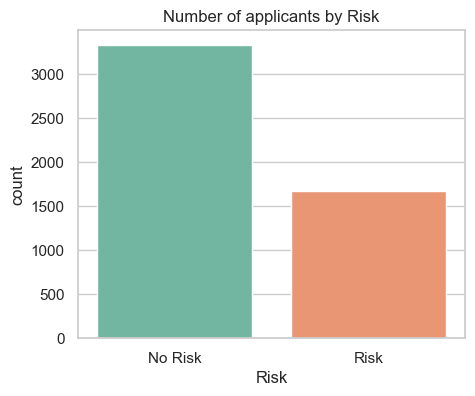

In [4]:
print(df["Risk"].value_counts())

# plot it
plt.figure(figsize=(5,4))
sns.countplot(x="Risk", data=df, palette="Set2")
plt.title("Number of applicants by Risk")
plt.show()

### A few quick visual insights

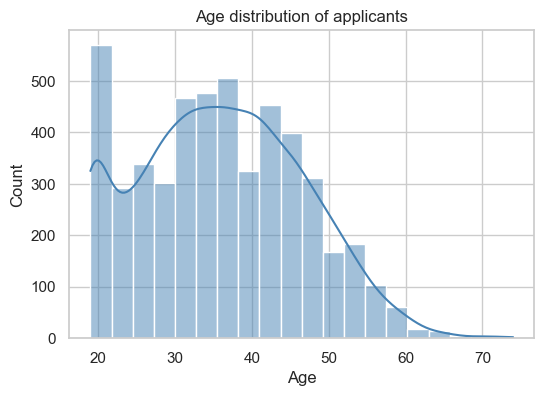

In [5]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True, color="steelblue")
plt.title("Age distribution of applicants")
plt.xlabel("Age")
plt.show()

/var/folders/9f/l7yrb1vn2lj3b_prvh88ygw40000gn/T/ipykernel_13911/1835600064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y="LoanAmount", data=df, palette="Set2")


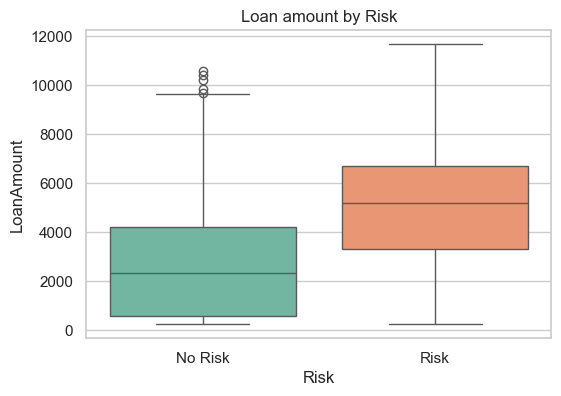

In [6]:
# Loan amount by Risk — do risky applicants ask for more?
plt.figure(figsize=(6,4))
sns.boxplot(x="Risk", y="LoanAmount", data=df, palette="Set2")
plt.title("Loan amount by Risk")
plt.show()

## 4. Prepare the data for machine learning

Machine learning models only understand **numbers**, but many of our columns are text (like `CheckingStatus` or `CreditHistory`). We need to:

1. Turn the target `Risk` into 0 / 1
2. Convert the text feature columns into numbers using **one-hot encoding** (`pd.get_dummies`)

In [7]:
# 1. Target: No Risk -> 0, Risk -> 1
df["Risk"] = df["Risk"].map({"No Risk": 0, "Risk": 1})

# 2. Separate features (X) from the target (y)
X = df.drop("Risk", axis=1)
y = df["Risk"]

# 3. Convert all text columns into numeric 0/1 columns
X = pd.get_dummies(X, drop_first=True)

print("Feature columns after encoding:", X.shape[1])
X.head()

Feature columns after encoding: 47


,LoanDuration,LoanAmount,InstallmentPercent,CurrentResidenceDuration,Age,ExistingCreditsCount,Dependents,CheckingStatus_greater_200,CheckingStatus_less_0,CheckingStatus_no_checking,...,OwnsProperty_unknown,InstallmentPlans_none,InstallmentPlans_stores,Housing_own,Housing_rent,Job_skilled,Job_unemployed,Job_unskilled,Telephone_yes,ForeignWorker_yes
0,31,1889,3,3,32,1,1,False,False,False,...,False,True,False,True,False,True,False,False,False,True
1,18,462,2,2,37,2,1,False,True,False,...,False,False,True,True,False,True,False,False,False,True
2,15,250,2,3,28,2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
3,28,3693,3,2,32,1,1,False,False,False,...,False,True,False,True,False,True,False,False,False,True
4,28,6235,3,3,57,2,1,False,False,True,...,True,True,False,True,False,True,False,False,False,True


## 5. Split into training and test sets

We train the model on 80% of the data and keep 20% aside to test it on data it has never seen — that tells us if it really learned, or just memorised.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 4000
Test rows: 1000


## 6. Train two models

We'll try two common classifiers and compare them:
- **Logistic Regression** — a simple, fast baseline
- **Random Forest** — a more powerful model made of many decision trees

In [12]:
# Logistic Regression
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, logreg_preds), 3))
print("Random Forest accuracy:      ", round(accuracy_score(y_test, rf_preds), 3))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression accuracy: 0.798
Random Forest accuracy:       0.808


## 7. Evaluate the better model

Accuracy alone can be misleading, so we also look at a **confusion matrix** (what it got right vs wrong) and a **classification report** (precision & recall).

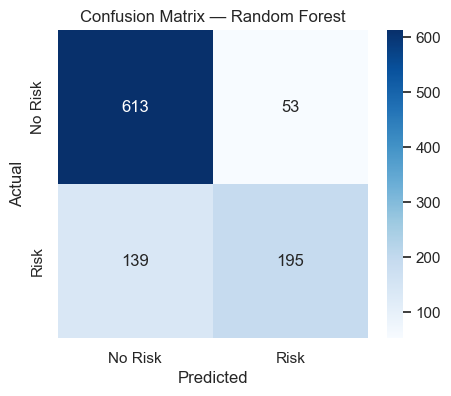

              precision    recall  f1-score   support

     No Risk       0.82      0.92      0.86       666
        Risk       0.79      0.58      0.67       334

    accuracy                           0.81      1000
   macro avg       0.80      0.75      0.77      1000
weighted avg       0.81      0.81      0.80      1000



In [10]:
# confusion matrix for Random Forest
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Risk", "Risk"],
            yticklabels=["No Risk", "Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()

print(classification_report(y_test, rf_preds, target_names=["No Risk", "Risk"]))

## 8. Which features matter most?

The Random Forest can tell us which pieces of information were most useful for predicting risk.

/var/folders/9f/l7yrb1vn2lj3b_prvh88ygw40000gn/T/ipykernel_13911/4141522033.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="viridis")


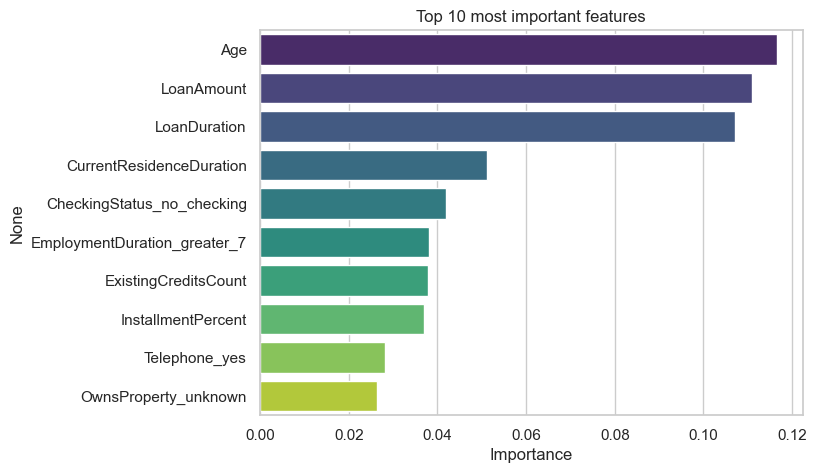

In [11]:
# get the top 10 most important features
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top 10 most important features")
plt.xlabel("Importance")
plt.show()

## 9. Conclusion

- We built a model that predicts whether a loan applicant is a credit risk.
- The **Random Forest** performed well and told us which factors (like loan amount, duration, and checking-account status) matter most.

**What I learned:** the full machine-learning workflow — loading data, exploring it, turning text into numbers, training and comparing models, and reading the results honestly.

**Next steps to try:**
- Balance the classes or tune the model to improve recall on the "Risk" group.
- Test other models (e.g. Gradient Boosting).
- Note: this dataset is a *biased* training sample, so a real deployment would need careful fairness checks — especially around features like `Sex` and `ForeignWorker`.
